In [3]:
import config
import os

In [40]:
repbase_update_dir = config.DIR_REPBASE_RAW

In [20]:
import json

with open(f"{config.DIR_REPBASE_RAW}/rep_dict.json", "r", encoding="utf-8") as f:
    rep_dict = json.load(f)

In [21]:
rep_dict

{'Transposable Element': {'DNA transposon': {'Mariner/Tc1': {},
   'hAT': {},
   'MuDR': {},
   'EnSpm/CACTA': {},
   'piggyBac': {},
   'P': {},
   'Merlin': {},
   'Harbinger': {},
   'Transib': {},
   'Novosib': {},
   'Helitron': {},
   'Polinton': {},
   'Kolobok': {},
   'ISL2EU': {},
   'Crypton': {'CryptonA': {},
    'CryptonF': {},
    'CryptonI': {},
    'CryptonS': {},
    'CryptonV': {}},
   'Sola': {'Sola1': {}, 'Sola2': {}, 'Sola3': {}},
   'Zator': {},
   'Ginger1': {},
   'Ginger2/TDD': {},
   'Academ': {},
   'Zisupton': {},
   'IS3EU': {},
   'Dada': {},
   'IS481EU': {},
   'Replitron': {}},
  'LTR Retrotransposon': {'Gypsy': {},
   'Copia': {},
   'BEL': {},
   'DIRS': {},
   'Troyka': {},
   'Lodin': {}},
  'Endogenous Retrovirus': {'ERV1': {},
   'ERV2': {},
   'ERV3': {},
   'Lentivirus': {},
   'ERV4': {},
   'Lokiretrovirus': {},
   'Spumaretrovirus': {}},
  'Non-LTR Retrotransposon': {'SINE': {'SINE1/7SL': {},
    'SINE2/tRNA': {},
    'SINE3/5S': {},
    'SIN

In [22]:
rep_dict.pop('Simple Repeat')
rep_dict.pop('Multicopy gene')
rep_dict.pop('Integrated Virus')
rep_dict['Transposable Element']['DNA transposon'].pop('Polinton')
rep_dict['Transposable Element']['DNA transposon'].pop('ISL2EU')
rep_dict['Transposable Element']['DNA transposon'].pop('Crypton')
rep_dict['Transposable Element']['DNA transposon'].pop('IS3EU')
rep_dict['Transposable Element']['DNA transposon'].pop('Dada')
rep_dict['Transposable Element']['DNA transposon'].pop('IS481EU')
rep_dict['Transposable Element'].pop('Endogenous Retrovirus')

{'ERV1': {},
 'ERV2': {},
 'ERV3': {},
 'Lentivirus': {},
 'ERV4': {},
 'Lokiretrovirus': {},
 'Spumaretrovirus': {}}

In [29]:
def flatten_rep_dict(d, names=None):
    if names is None:
        names = set()

    for key, value in d.items():
        names.add(key)
        if isinstance(value, dict) and value:
            flatten_rep_dict(value, names)

    return names

In [30]:
flatten_rep = flatten_rep_dict(rep_dict)
flatten_rep

{'Academ',
 'Ambal',
 'Athena',
 'BEL',
 'CR1',
 'CRE',
 'Copia',
 'Coprina',
 'Crack',
 'DIRS',
 'DNA transposon',
 'Daphne',
 'EnSpm/CACTA',
 'Ginger1',
 'Ginger2/TDD',
 'Gypsy',
 'Harbinger',
 'Helitron',
 'Hero',
 'Hydra',
 'I',
 'Ingi',
 'Jockey',
 'Kiri',
 'Kolobok',
 'L1',
 'L2',
 'L2A',
 'L2B',
 'LTR Retrotransposon',
 'Loa',
 'Lodin',
 'Mariner/Tc1',
 'Merlin',
 'MuDR',
 'Naiad/Chlamys',
 'NeSL',
 'Nematis',
 'Neptune',
 'Nimb',
 'Non-LTR Retrotransposon',
 'Novosib',
 'Outcast',
 'P',
 'Penelope',
 'Penelope/Poseidon',
 'Proto1',
 'Proto2',
 'R1',
 'R2',
 'R4',
 'RTE',
 'RTETP',
 'RTEX',
 'RandI',
 'Replitron',
 'Rex1',
 'SINE',
 'SINE1/7SL',
 'SINE2/tRNA',
 'SINE3/5S',
 'SINE4',
 'SINEU/snRNA',
 'Sola',
 'Sola1',
 'Sola2',
 'Sola3',
 'Tad1',
 'Transib',
 'Transposable Element',
 'Troyka',
 'Tx1',
 'Vingi',
 'Zator',
 'Zisupton',
 'hAT',
 'piggyBac'}

In [41]:
import os

def collect_to_fasta(root_dir, output_file):
    with open(output_file, "w", encoding="utf-8") as out:
        for path, _, files in os.walk(root_dir):
            for f in files:
                if f.endswith("rep.ref"):
                    with open(os.path.join(path, f), encoding="utf-8", errors="ignore") as inp:
                        for line in inp:
                            if line.strip():
                                out.write(line)

collect_to_fasta(repbase_update_dir, f"{config.DIR_REPBASE_PREPROCESSED}/all.fasta")

In [42]:
def parse_headers(fasta_file):
    with open(fasta_file, encoding="utf-8") as f:
        for line in f:
            if line.startswith(">"):
                yield line[1:].strip().split("\t")

In [55]:
def build_class_depths(tree, depth=0, depths=None):
    if depths is None:
        depths = {}

    for cls, children in tree.items():
        depths[cls] = depth
        build_class_depths(children, depth + 1, depths)

    return depths


class_depth = build_class_depths(rep_dict)


def filter_fasta(input_file, output_file):
    best_records = {}

    with open(input_file) as inp:
        header, seq = None, []

        for line in inp:
            if line.startswith(">"):
                if header:
                    process_sequence(header, "".join(seq), best_records)
                header, seq = line, []
            else:
                seq.append(line)

        if header:
            process_sequence(header, "".join(seq), best_records)

    with open(output_file, "w") as out:
        for rec in best_records.values():
            out.write(rec["header"] + rec["sequence"])

    print(f"Found {len(best_records)} sequences in {input_file}")


def process_sequence(header, sequence, best_records):
    parts = header[1:].strip().split("\t")
    if len(parts) < 2:
        print(parts)
        return

    seq_id = parts[0]
    cls = parts[1]
    seq_clean = sequence.replace("\n", "")

    if cls not in flatten_rep:
        return

    if len(seq_clean) > 20000:
        return

    new_depth = class_depth.get(cls, -1)

    if seq_id not in best_records:
        best_records[seq_id] = {
            "header": header,
            "sequence": sequence,
            "class": cls,
        }
        return

    old_cls = best_records[seq_id]["class"]
    old_depth = class_depth.get(old_cls, -1)

    if cls != old_cls:
        print(f"DUPLICATE: {seq_id}: old={old_cls}, new={cls}")

    # оставляем самый "низкий" класс = самый глубокий в иерархии
    if new_depth > old_depth:
        print("Update", new_depth, old_depth)
        best_records[seq_id] = {
            "header": header,
            "sequence": sequence,
            "class": cls,
        }

In [56]:
filter_fasta(f"{config.DIR_REPBASE_PREPROCESSED}/all.fasta", f"{config.DIR_REPBASE_PREPROCESSED}/all_maxlen20_filterclasses.fasta")

DUPLICATE: BoSB15: old=SINE2/tRNA, new=SINE
DUPLICATE: SONATA2: old=Mariner/Tc1, new=DNA transposon
DUPLICATE: GmGYPSY11_I: old=Gypsy, new=LTR Retrotransposon
DUPLICATE: RAM13_I_MT: old=Gypsy, new=Copia
DUPLICATE: BoSB11: old=SINE2/tRNA, new=SINE
DUPLICATE: TE-7-1_VV: old=hAT, new=Transposable Element
DUPLICATE: BoSB8B: old=SINE2/tRNA, new=SINE
DUPLICATE: BoSB6D: old=SINE2/tRNA, new=SINE
DUPLICATE: SONATA1: old=Mariner/Tc1, new=DNA transposon
DUPLICATE: SONATA3: old=Mariner/Tc1, new=DNA transposon
DUPLICATE: BoSB13: old=SINE2/tRNA, new=SINE
DUPLICATE: PIGMET: old=Mariner/Tc1, new=DNA transposon
DUPLICATE: BoSB9B: old=SINE2/tRNA, new=SINE
DUPLICATE: BoSB2: old=SINE2/tRNA, new=SINE
DUPLICATE: SHELI_MT: old=MuDR, new=DNA transposon
DUPLICATE: BoSB5A: old=SINE2/tRNA, new=SINE
DUPLICATE: BoSB5C: old=SINE2/tRNA, new=SINE
DUPLICATE: BoSB12: old=SINE2/tRNA, new=SINE
DUPLICATE: BoSB14A: old=SINE2/tRNA, new=SINE
DUPLICATE: BoSB6A: old=SINE2/tRNA, new=SINE
DUPLICATE: BoSB7A: old=SINE2/tRNA, new=S

In [59]:
f"{config.DIR_REPBASE_PREPROCESSED}/all_maxlen20_filterclasses.fasta"

'/Users/nad/hse/semester08/mobiraph/data/n14_repbase_preprocessed/all_maxlen20_filterclasses.fasta'

In [ ]:
!makeblastdb -in '/Users/nad/hse/semester08/mobiraph/data/n14_repbase_preprocessed/all_maxlen20_filterclasses.fasta' -dbtype nucl -out seqs_db

In [ ]:
# *%%bash
# blastn \
#   -query /Users/nad/hse/semester08/mobiraph/data/n14_repbase_preprocessed/all_maxlen20.fasta \
#   -db seqs_db \
#   -outfmt "6 qseqid sseqid pident length qlen slen qcovs evalue bitscore" \
#   -out /Users/nad/hse/semester08/mobiraph/data/n14_repbase_preprocessed/all_vs_all.tsv

In [61]:
!awk '$1 != $2 && $3 >= 80 && $4/$5 >= 0.8 && $4/$6 >= 0.8' /Users/nad/hse/semester08/mobiraph/data/n14_repbase_preprocessed/all_vs_all.tsv > /Users/nad/hse/semester08/mobiraph/data/n14_repbase_preprocessed/all_vs_all_filtered.tsv

In [62]:
from collections import defaultdict

def clean_id(x):
    return x.split()[0]

pairs = []
with open(f"{config.DIR_REPBASE_PREPROCESSED}/all_vs_all_filtered.tsv") as f:
    for line in f:
        parts = line.strip('\t').split()
        if len(parts) < 2:
            continue
        q = clean_id(parts[0])
        s = clean_id(parts[1])
        if q == s:
            continue
        pairs.append((q, s))

graph = defaultdict(set)
for a, b in pairs:
    graph[a].add(b)
    graph[b].add(a)

visited = set()
clusters = []

def dfs(start):
    cluster = set()
    stack = [start]
    while stack:
        n = stack.pop()
        if n in visited:
            continue
        visited.add(n)
        cluster.add(n)
        stack.extend(graph[n] - visited)
    return cluster

for node in graph:
    if node not in visited:
        clusters.append(dfs(node))

remove = set()

for cluster in clusters:
    rep = max(cluster, key=lambda x: len(graph[x]))
    remove.update(cluster - {rep})

with open(f"{config.DIR_REPBASE_PREPROCESSED}/remove_ids02.txt", "w") as f:
    for x in sorted(remove):
        f.write(x + "\n")

print(f"Удалить: {len(remove)} последовательностей")

Удалить: 9188 последовательностей


In [63]:
def filter_fasta2(input_file, output_file):
    i = 0

    with open(input_file) as inp, open(output_file, "w") as out:
        header, seq = None, []

        for line in inp:
            if line.startswith(">"):
                if header and keep_sequence2(header, "".join(seq)):
                    i += 1
                    out.write(header + "".join(seq))
                header, seq = line, []
            else:
                seq.append(line)

        if header and keep_sequence2(header, "".join(seq)):
            i += 1
            out.write(header + "".join(seq))
    print(f"Found {i} sequences in {input_file}")


def keep_sequence2(header, sequence):
    parts = header[1:].strip().split("\t")
    if len(parts) < 2:
        print(parts)
        return False
    if parts[0] in remove:
        return False
    return True

In [64]:
filter_fasta2(f"{config.DIR_REPBASE_PREPROCESSED}/all_maxlen20_filterclasses.fasta", f"{config.DIR_REPBASE_PREPROCESSED}/all_maxlen20_filterclasses_blast.fasta")

Found 96570 sequences in /Users/nad/hse/semester08/mobiraph/data/n14_repbase_preprocessed/all_maxlen20_filterclasses.fasta


## Разделение на классы, в которых больше 500 и на "остальные"

In [156]:
from collections import Counter

class_to_items = {}

def read_fasta_headers(filepath):
    headers = []
    with open(filepath, "r") as f:
        for line in f:
            if line.startswith(">"):
                headers.append(line.strip()[1:])
    return headers


def count_classes_from_fasta(filepath):
    headers = read_fasta_headers(filepath)

    second_values = []
    for h in headers:
        parts = h.split("\t")
        if len(parts) > 1:
            second_values.append(parts[1])
            class_to_items.setdefault(parts[1], []).append(parts[0])

    return Counter(second_values)

counts = count_classes_from_fasta(f"{config.DIR_REPBASE_PREPROCESSED}/all_maxlen20_filterclasses_blast.fasta")
print(counts)

Counter({'Gypsy': 33687, 'Copia': 11370, 'BEL': 8141, 'hAT': 7040, 'Mariner/Tc1': 4235, 'L1': 3835, 'MuDR': 2577, 'Harbinger': 2394, 'DNA transposon': 2224, 'Helitron': 1969, 'DIRS': 1786, 'EnSpm/CACTA': 1406, 'SINE2/tRNA': 1047, 'CR1': 1041, 'RTEX': 935, 'LTR Retrotransposon': 925, 'Troyka': 924, 'Neptune': 911, 'Kolobok': 905, 'RTE': 662, 'piggyBac': 653, 'Academ': 624, 'Tad1': 560, 'Tx1': 509, 'Daphne': 429, 'Non-LTR Retrotransposon': 412, 'L2': 401, 'Jockey': 352, 'P': 341, 'Penelope/Poseidon': 338, 'R1': 303, 'Transib': 256, 'I': 239, 'Transposable Element': 233, 'Nimb': 208, 'Sola1': 186, 'Merlin': 182, 'Crack': 179, 'R2': 171, 'Sola2': 169, 'Rex1': 160, 'Vingi': 149, 'Kiri': 137, 'NeSL': 116, 'Naiad/Chlamys': 115, 'Zator': 110, 'CRE': 100, 'Loa': 89, 'Proto2': 89, 'SINE': 75, 'Ginger2/TDD': 69, 'R4': 65, 'Outcast': 55, 'Sola3': 52, 'Ingi': 46, 'Zisupton': 43, 'Hero': 35, 'Replitron': 32, 'Athena': 32, 'SINE3/5S': 28, 'Hydra': 28, 'Penelope': 27, 'L2B': 26, 'SINE1/7SL': 24, 'Ging

In [158]:
from collections import defaultdict


def collect_subtree_nodes(node_name, subtree):
    """
    Все узлы поддерева, включая сам node_name.
    """
    result = {node_name}
    for child_name, child_subtree in subtree.items():
        result.update(collect_subtree_nodes(child_name, child_subtree))
    return result


def compute_subtree_sizes(hierarchy, class_counts):
    """
    Считает суммарное число примеров в каждом поддереве.
    subtree_sizes[node] = count(node) + count(всех потомков)
    """
    subtree_sizes = {}

    def dfs(node_name, subtree):
        total = class_counts.get(node_name, 0)
        for child_name, child_subtree in subtree.items():
            total += dfs(child_name, child_subtree)
        subtree_sizes[node_name] = total
        return total

    for root_name, root_subtree in hierarchy.items():
        dfs(root_name, root_subtree)

    return subtree_sizes


def prune_hierarchy_with_other(hierarchy, class_counts, class_to_items, threshold=500):
    """
    На каждом уровне среди непосредственных детей узла:
    - оставляет детей, у которых размер поддерева > threshold
    - остальных объединяет в {parent}_other

    Возвращает:
    - new_hierarchy
    - translation_dict: old_class -> new_class
    - new_counts: count по новым классам
    - subtree_sizes
    """
    subtree_sizes = compute_subtree_sizes(hierarchy, class_counts)
    translation_dict = {}

    def dfs(node_name, subtree, forced_target=None):
        """
        forced_target != None означает, что весь этот узел уже схлопнут выше.
        """
        if forced_target is not None:
            all_nodes = collect_subtree_nodes(node_name, subtree)
            for cls in all_nodes:
                translation_dict[cls] = forced_target
            return None

        translation_dict.setdefault(node_name, node_name)

        new_children = {}
        small_children = []

        for child_name, child_subtree in subtree.items():
            child_size = subtree_sizes[child_name]

            if child_size > threshold:
                pruned_child = dfs(child_name, child_subtree)
                new_children[child_name] = pruned_child if pruned_child is not None else {}
            else:
                small_children.append((child_name, child_subtree))

        if small_children:
            other_name = f"{node_name}_other"
            new_children[other_name] = {}

            for child_name, child_subtree in small_children:
                all_nodes = collect_subtree_nodes(child_name, child_subtree)
                for cls in all_nodes:
                    translation_dict[cls] = other_name

        return new_children

    new_hierarchy = {}
    for root_name, root_subtree in hierarchy.items():
        new_hierarchy[root_name] = dfs(root_name, root_subtree)

    # новые counts после переименования
    new_counts = defaultdict(int)
    for old_class, count in class_counts.items():
        new_class = translation_dict.get(old_class, old_class)
        new_counts[new_class] += count


    # новые items после переименования
    new_class_to_items = defaultdict(list)
    for old_class, items in class_to_items.items():
        new_class = translation_dict.get(old_class, old_class)
        new_class_to_items[new_class].extend(items)

    return new_hierarchy, translation_dict, dict(new_counts), dict(new_class_to_items), subtree_sizes

In [162]:
new_rep_dict, translation_dict, new_counts, new_class_to_items, subtree_sizes = prune_hierarchy_with_other(
    rep_dict,
    counts,
    class_to_items,
    threshold=500
)

In [ ]:
new_class_to_items

## Корректировка конкретно для SINE

In [165]:
new_rep_dict['Transposable Element']['Non-LTR Retrotransposon']['SINE'] = {}

In [166]:
for key, value in translation_dict.items():
    if translation_dict[key] == 'SINE2/tRNA' or translation_dict[key] == 'SINE_other':
        translation_dict[key] = 'SINE'

In [167]:
new_counts["SINE"] += new_counts.pop('SINE_other') + new_counts.pop('SINE2/tRNA')
new_counts["SINE"]

1187

In [ ]:
new_class_to_items["SINE"] += new_class_to_items.pop('SINE_other') + new_class_to_items.pop('SINE2/tRNA')

## Leave only classes bigger than 50 sequences

In [169]:
filtered_counts = {
    cls: cnt
    for cls, cnt in new_counts.items()
    if cnt > 50
}

## Запись в файлы после обработки

In [170]:
import json

with open(f"{config.DIR_REPBASE_PROCESSED}/translation_dict.json", "w", encoding="utf-8") as f:
    json.dump(translation_dict, f, ensure_ascii=False, indent=2)

In [171]:
import json


def save_filtered_fasta_and_metadata(translation_dict, filtered_counts):
    input_fasta = f"{config.DIR_REPBASE_PREPROCESSED}/all_maxlen20_filterclasses_blast.fasta"
    output_fasta = f"{config.DIR_REPBASE_PROCESSED}/all_sequences_filtered_02.fasta"
    output_meta = f"{config.DIR_REPBASE_PROCESSED}/metadata_02.json"

    valid_classes = set(filtered_counts.keys())
    seen_ids = set()
    metadata_02 = {}

    written = 0
    total = 0
    skipped_no_translation = 0
    skipped_not_in_filtered = 0

    with open(input_fasta, "r") as inp, open(output_fasta, "w") as out:
        header = None
        seq = []

        def process_record(header, seq_lines):
            nonlocal written, total, skipped_no_translation, skipped_not_in_filtered

            if header is None:
                return

            total += 1

            parts = header[1:].strip().split("\t")
            assert len(parts) >= 3, f"Header has less than 3 fields: {header!r}"

            seq_id = parts[0]
            old_class = parts[1]
            organism = parts[2]

            assert seq_id not in seen_ids, f"Duplicate seq_id found: {seq_id}"
            seen_ids.add(seq_id)

            new_class = translation_dict.get(old_class)
            if new_class is None:
                skipped_no_translation += 1
                return

            if new_class not in valid_classes:
                skipped_not_in_filtered += 1
                return

            sequence = "".join(seq_lines).strip()
            out.write(f">{seq_id}\n{sequence}\n")

            metadata_02[seq_id] = {
                "class": new_class,
                "organism": organism,
            }

            written += 1

        for line in inp:
            if line.startswith(">"):
                process_record(header, seq)
                header = line
                seq = []
            else:
                seq.append(line.strip())

        process_record(header, seq)

    with open(output_meta, "w", encoding="utf-8") as f:
        json.dump(metadata_02, f, ensure_ascii=False, indent=2)

    print(f"Total records: {total}")
    print(f"Written records: {written}")
    print(f"Skipped (no translation): {skipped_no_translation}")
    print(f"Skipped (class not in filtered_counts): {skipped_not_in_filtered}")
    print(f"Saved fasta: {output_fasta}")
    print(f"Saved metadata: {output_meta}")

In [172]:
save_filtered_fasta_and_metadata(translation_dict, filtered_counts)

Total records: 96570
Written records: 96537
Skipped (no translation): 0
Skipped (class not in filtered_counts): 33
Saved fasta: /Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/all_sequences_filtered_02.fasta
Saved metadata: /Users/nad/hse/semester08/mobiraph/data/n13_repbase_processed/metadata_02.json


## Сохраняем файл с иерархией и индексами последовательностей

In [175]:
import numpy as np
def build_hierarchy_sequences(name, dict_in):
    if name not in filtered_counts.keys():
        return None
    sequences = []
    subs = {}
    for child in dict_in[name].keys():
        dict_child = build_hierarchy_sequences(child, {child: dict_in[name][child]})
        if not dict_child:
            continue
        print(dict_child)
        sequences.extend(dict_child["sequences"])
        subs = {**subs, **{child: dict_child}}
    dict_out = {}
    dict_out["sequences"] = new_class_to_items[name] + sequences
    dict_out["subs"] = subs
    return dict_out


In [179]:
hierarchy_sequences = {'Transposable Element': build_hierarchy_sequences('Transposable Element', new_rep_dict)}
with open(f"{config.DIR_REPBASE_PROCESSED}/hierarchy_sequences_02.json", "w", encoding="utf-8") as f:
        json.dump(hierarchy_sequences['Transposable Element']['subs'], f, ensure_ascii=False, indent=2)

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [126]:
def build_rep_dict_counts(name, dict_in):
    sum_children = 0
    dict_children = {}
    for child in dict_in[name].keys():
        dict_child = build_rep_dict_counts(child, {child: dict_in[name][child]})
        sum_children += dict_child["subtree_count"]
        dict_children = {**dict_children, **{child: dict_child}}
    dict_out = {}
    dict_out["self_count"] = new_counts[name]
    dict_out["subtree_count"] = sum_children + dict_out["self_count"]
    dict_out["children"] = dict_children
    return dict_out

In [127]:
new_rep_dict_counts = {'Transposable Element': build_rep_dict_counts('Transposable Element', new_rep_dict)}
new_rep_dict_counts

{'Transposable Element': {'self_count': 233,
  'subtree_count': 96570,
  'children': {'DNA transposon': {'self_count': 2224,
    'subtree_count': 25497,
    'children': {'Mariner/Tc1': {'self_count': 4235,
      'subtree_count': 4235,
      'children': {}},
     'hAT': {'self_count': 7040, 'subtree_count': 7040, 'children': {}},
     'MuDR': {'self_count': 2577, 'subtree_count': 2577, 'children': {}},
     'EnSpm/CACTA': {'self_count': 1406,
      'subtree_count': 1406,
      'children': {}},
     'piggyBac': {'self_count': 653, 'subtree_count': 653, 'children': {}},
     'Harbinger': {'self_count': 2394, 'subtree_count': 2394, 'children': {}},
     'Helitron': {'self_count': 1969, 'subtree_count': 1969, 'children': {}},
     'Kolobok': {'self_count': 905, 'subtree_count': 905, 'children': {}},
     'Academ': {'self_count': 624, 'subtree_count': 624, 'children': {}},
     'DNA transposon_other': {'self_count': 1470,
      'subtree_count': 1470,
      'children': {}}}},
   'LTR Retrotra

In [180]:
from graphviz import Digraph


def build_graphviz_tree(annotated_tree: dict, output_name: str = "taxonomy_tree"):
    dot = Digraph(comment="Taxonomy tree")
    dot.attr(rankdir="TB")
    dot.attr("node", shape="box", style="rounded,filled", fillcolor="lightyellow")

    node_counter = 0

    def add_nodes(subtree: dict, parent_id: str | None = None):
        nonlocal node_counter

        for name, data in subtree.items():
            if name not in filtered_counts.keys():
                continue
            node_id = f"node_{node_counter}"
            node_counter += 1

            label = f"{name}\n{data['subtree_count']}"
            dot.node(node_id, label)

            if parent_id is not None:
                dot.edge(parent_id, node_id)

            add_nodes(data["children"], node_id)

    add_nodes(annotated_tree)

    dot.render(output_name, format="pdf", cleanup=True)
    return dot

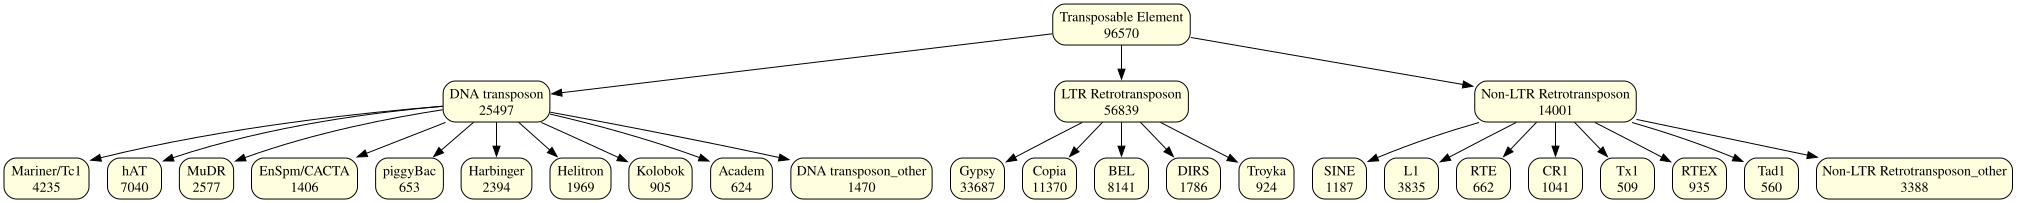

In [181]:
build_graphviz_tree(new_rep_dict_counts, output_name=f"{config.DIR_FIGURES}/transposon_taxonomy_tree_07")